# 🧥 MeshVTON — 3D Inference (Final)

**Girdi:** 2D kişi görseli + 3D kıyafet objesi (.obj)
**Çıktı:** kişi, kıyafeti giymiş halde

Kıyafet: database'den rastgele çekilebilir **veya** kendi `.obj`'unu yükleyebilirsin.

Akış: kişi → densepose + mask | 3D mesh → render (RGB+normal+depth) → eğitilmiş ControlNet3D → diffusion.

> Kurulum ~15-20 dk (detectron2 derleme + model indirme). Bir kere.

## 1️⃣ GPU + repolar

In [1]:
import os, torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'YOK')
if not os.path.exists('/content/MeshVTON'):
    !git clone https://github.com/SerhanTelatar/MeshVTON.git /content/MeshVTON
else:
    !cd /content/MeshVTON && git pull
if not os.path.exists('/content/IDM-VTON-official'):
    !git clone https://github.com/yisol/IDM-VTON.git /content/IDM-VTON-official
print('✅ repolar hazır')

GPU: NVIDIA A100-SXM4-80GB
Cloning into '/content/MeshVTON'...
remote: Enumerating objects: 504, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 504 (delta 2), reused 6 (delta 2), pack-reused 493 (from 1)
Receiving objects: 100% (504/504), 6.21 MiB | 28.12 MiB/s, done.
Resolving deltas: 100% (284/284), done.
Cloning into '/content/IDM-VTON-official'...
remote: Enumerating objects: 1502, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 1502 (delta 103), reused 80 (delta 80), pack-reused 1238 (from 2)
Receiving objects: 100% (1502/1502), 22.19 MiB | 17.19 MiB/s, done.
Resolving deltas: 100% (407/407), done.
✅ repolar hazır


## 2️⃣ Kütüphaneler (+ detectron2 ~15dk) + Drive

In [2]:
os.environ["TOKENIZERS_PARALLELISM"]="false"; os.environ["FORCE_CUDA"]="1"
from google.colab import drive; drive.mount('/content/drive')
!pip install -q diffusers==0.25.0 transformers==4.36.2 accelerate==0.25.0 huggingface_hub==0.20.3 peft==0.7.1
!pip install -q omegaconf opencv-python-headless einops av onnxruntime-gpu==1.17.1 fvcore iopath smplx trimesh
!pip install -q /content/drive/MyDrive/wheels/pytorch3d*.whl
!pip install -q -U onnxruntime
try:
    import detectron2
except Exception:
    !pip install 'git+https://github.com/facebookresearch/detectron2.git'
import detectron2; print('✅ detectron2', detectron2.__version__)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 156.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.20.3 which is incompatible.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.

## 3️⃣ Ön-işleme model dosyaları

In [3]:
import shutil
from huggingface_hub import hf_hub_download
base='/content/IDM-VTON-official/ckpt'
dp=f'{base}/densepose/model_final_162be9.pkl'; os.makedirs(os.path.dirname(dp),exist_ok=True)
if not os.path.exists(dp) or os.path.getsize(dp)<1e6:
    !wget -q https://dl.fbaipublicfiles.com/densepose/densepose_rcnn_R_50_FPN_s1x/165712039/model_final_162be9.pkl -O {dp}
for rf,d in {'humanparsing/parsing_atr.onnx':f'{base}/humanparsing/parsing_atr.onnx',
             'humanparsing/parsing_lip.onnx':f'{base}/humanparsing/parsing_lip.onnx',
             'openpose/ckpts/body_pose_model.pth':f'{base}/openpose/ckpts/body_pose_model.pth'}.items():
    if not os.path.exists(d) or os.path.getsize(d)<1e6:
        os.makedirs(os.path.dirname(d),exist_ok=True); shutil.copy(hf_hub_download('yisol/IDM-VTON',rf),d)
print('✅ ön-işleme modelleri hazır')

parsing_atr.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

parsing_lip.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

body_pose_model.pth:   0%|          | 0.00/209M [00:00<?, ?B/s]

✅ ön-işleme modelleri hazır


## 4️⃣ Pipeline + ControlNet3D (eğitilmiş) yükle

In [5]:
import sys, torch, glob
for m in list(sys.modules):
    if m=='src' or m.startswith('src.'): del sys.modules[m]
sys.path.insert(0,'/content/MeshVTON')
from src.idm_vton.tryon_pipeline import StableDiffusionXLInpaintPipeline as TryonPipeline
from src.idm_vton.unet_hacked_tryon import UNet2DConditionModel
from src.idm_vton.unet_hacked_garmnet import UNet2DConditionModel as RefUNet
from src.models.controlnet_3d import ControlNet3D
from transformers import CLIPImageProcessor, CLIPVisionModelWithProjection, CLIPTextModel, CLIPTextModelWithProjection, AutoTokenizer
from diffusers import DDPMScheduler, AutoencoderKL
B='yisol/IDM-VTON'; dt=torch.float16
unet=UNet2DConditionModel.from_pretrained(B,subfolder="unet",torch_dtype=dt)
uenc=RefUNet.from_pretrained(B,subfolder="unet_encoder",torch_dtype=dt)
vae=AutoencoderKL.from_pretrained(B,subfolder="vae",torch_dtype=dt)
ie=CLIPVisionModelWithProjection.from_pretrained(B,subfolder="image_encoder",torch_dtype=dt)
t1=CLIPTextModel.from_pretrained(B,subfolder="text_encoder",torch_dtype=dt)
t2=CLIPTextModelWithProjection.from_pretrained(B,subfolder="text_encoder_2",torch_dtype=dt)
k1=AutoTokenizer.from_pretrained(B,subfolder="tokenizer",use_fast=False)
k2=AutoTokenizer.from_pretrained(B,subfolder="tokenizer_2",use_fast=False)
sch=DDPMScheduler.from_pretrained(B,subfolder="scheduler")
pipe=TryonPipeline.from_pretrained(B,unet=unet,vae=vae,feature_extractor=CLIPImageProcessor(),
    text_encoder=t1,text_encoder_2=t2,tokenizer=k1,tokenizer_2=k2,scheduler=sch,image_encoder=ie,torch_dtype=dt)
pipe.unet_encoder=uenc; pipe=pipe.to('cuda'); pipe.unet_encoder.to('cuda')

cands=glob.glob('/content/drive/MyDrive/MeshVTON/checkpoints_meshvton/controlnet3d_final.pt') \
    + sorted(glob.glob('/content/drive/MyDrive/MeshVTON/checkpoints_meshvton/controlnet3d_*.pt')) \
    + sorted(glob.glob('/content/MeshVTON/checkpoints_meshvton/*.pt'))
assert cands, "❌ ControlNet3D checkpoint yok (Drive/MeshVTON/checkpoints)"
controlnet=ControlNet3D(conditioning_channels=9).to('cuda',dt).eval()
controlnet.load_state_dict(torch.load(cands[0],map_location='cuda'))
print('✅ pipeline + ControlNet3D yüklendi:', cands[0])

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytre

config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/12.0G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

✅ pipeline + ControlNet3D yüklendi: /content/drive/MyDrive/MeshVTON/checkpoints_meshvton/controlnet3d_final.pt


## 5️⃣ Ön-işleme + 3D render modülleri

In [6]:
# --- 2D ön-işleme (IDM-VTON-official): parsing + openpose + densepose ---
sys.path.insert(0,'/content/IDM-VTON-official'); sys.path.insert(0,'/content/IDM-VTON-official/gradio_demo')
from preprocess.humanparsing.run_parsing import Parsing
from preprocess.openpose.run_openpose import OpenPose
from utils_mask import get_mask_location
import apply_net
from detectron2.data.detection_utils import convert_PIL_to_numpy, _apply_exif_orientation
parsing_model=Parsing(0); openpose_model=OpenPose(0)

# --- 3D conditioning modülleri (eğitimle TEK kaynak: build_conditioning_3d) ---
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from src.modules.mesh_renderer import MeshRenderer
from src.modules.garment_draper import GarmentDraper
from src.modules.smplx_estimator import RealSMPLXEstimator
from src.modules.conditioning3d import build_conditioning_3d, detect_facing, azim_from_facing, azim_from_2d

renderer = MeshRenderer(image_size=512, device='cuda'); renderer.setup()
draper   = GarmentDraper().to('cuda').eval()
print('✅ render + drape modülleri hazır (gerçek SMPL-X pozu için sonraki hücre)')

PyTorch3D renderer initialized: phong
✅ render + drape modülleri hazır (gerçek SMPL-X pozu için sonraki hücre)


In [7]:
# === Gerçek SMPL-X poz tahmini (4D-Humans / HMR2.0) ===
# Eski SimpleSMPLXRegressor EĞİTİLMEMİŞTİ → global_orient anlamsızdı (giysinin kişiye
# göre dönmemesinin kök nedeni). Artık görüntüden gerçek poz/yön tahmin ediyoruz.
import os, glob, shutil

# 1) SMPL-X neutral (renderer/draper) — Drive'dan
SMPLX_DIR = '/content/MeshVTON/checkpoints/pretrained/smplx'
os.makedirs(SMPLX_DIR, exist_ok=True)
for s in glob.glob('/content/drive/MyDrive/MeshVTON/smplx/SMPLX_NEUTRAL.*'):
    shutil.copy(s, SMPLX_DIR)
assert glob.glob(f'{SMPLX_DIR}/SMPLX_NEUTRAL.*'), \
    "SMPLX_NEUTRAL.npz yok → smpl-x.is.tue.mpg.de, Drive/MeshVTON/smplx/"

# 2) 4D-Humans
try:
    import hmr2  # noqa
except Exception:
    get_ipython().system('pip install -q git+https://github.com/shubham-goel/4D-Humans.git')

# 3) HMR2.0 ağırlıkları (~3.5 GB, bir kez)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)

# 4) SMPL neutral (HMR2 gövde modeli) — smplify.is.tue.mpg.de → Drive'dan
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob('/content/drive/MyDrive/MeshVTON/smpl/*neutral*lbs*.pkl') \
      + glob.glob('/content/drive/MyDrive/MeshVTON/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok → smplify.is.tue.mpg.de, Drive/MeshVTON/smpl/"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")

from src.modules.smplx_estimator import RealSMPLXEstimator
estimator = RealSMPLXEstimator(model_path='/content/MeshVTON/checkpoints/pretrained',
                               regressor='hmr2', device='cuda')
estimator.load_model()
print('✅ gerçek SMPL-X tahmincisi hazır (HMR2.0 → SMPL-X)')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



Extracting file: hmr2_data.tar.gz
SMPL-X model loaded: neutral


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`


✅ gerçek SMPL-X tahmincisi hazır (HMR2.0 → SMPL-X)


## 6️⃣ Kıyafet seç + önizle

**A** (kendi .obj) veya **B** (database'den rastgele) hücresini çalıştır. İkisi de `MESH_PATH`
ayarlar + önizleme gösterir. Önizlemede **tişört/giysi dik & önden** görüneni seç.

In [11]:
from google.colab import files
print("🧵 3D KIYAFET yükle — .obj + texture(.png/.jpg) BİRLİKTE seç (CLOTH3D: obj + texture png):")
_up = files.upload()
_objs = [k for k in _up if k.lower().endswith('.obj')]
_imgs = [k for k in _up if k.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
MESH_PATH = _objs[0] if _objs else list(_up.keys())[0]
TEXTURE_PATH = _imgs[0] if _imgs else None
print("kıyafet:", MESH_PATH, "| texture:", TEXTURE_PATH or "(YOK → gri render, desen gelmez!)")


🧵 3D KIYAFET yükle — .obj + texture(.png/.jpg) BİRLİKTE seç (CLOTH3D: obj + texture png):


Saving mesh.obj to mesh (1).obj
kıyafet: mesh (1).obj | texture: (YOK → gri render, desen gelmez!)


## 7️⃣ Açıyı ayarla

Önizlemede giysinin **dik & önden** göründüğü kareyi bul, `axis,deg` değerini buraya yaz.
(CLOTH3D database mesh'leri için genelde `'x', -90` doğru.)

In [12]:
# None → açı kişinin pozundan otomatik. Sabit istersen: 0 (ön) / 90 (yan) / 180 (arka)
VIEW_ANGLE = None
print("VIEW_ANGLE =", VIEW_ANGLE)

VIEW_ANGLE = None


## 8️⃣ Kişileri yükle + Try-On (çoklu kişi, aynı kıyafet)

In [13]:
from torchvision import transforms
from pathlib import Path
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
device = 'cuda'; dt = torch.float16
H, W = 512, 384   # eğitimle aynı kanonik çözünürlük (parite)
# Maske modu: 'default' = IDM-VTON upper_body agnostic (önerilen başlangıç).
# 'union' = giysi silüetini maskeye EKLE (uzun kol/şekli boyamaya izin verir; yan profilde blob riski).
# 'intersect' = maskeyi giysi silüetine kıs (kolsuz/crop sadakati).
MASK_MODE = 'default'

# ControlNet3D ölçeği: 0.0 = KAPALI (cn OFF). Pratikte en iyi: render conditioning
# güvenilmez (yan profilde bozuk render) + 3D ControlNet checkpoint zayıf olduğundan
# AÇIK iken şekli YANLIŞ zorluyor (kısa kol/yanlış renk). cn OFF iken giysi, IDM-VTON'un
# güçlü IP-Adapter/GarmentNet (cloth + ip_adapter_image) yolundan gelir → daha sadık.
# 0<scale<1 ile kısmi enjeksiyon dene (ör. 0.3).
CONTROLNET_SCALE = 0.0

# Kategori (mask bölgesi) — dosya adından
name_lower = MESH_PATH.lower()
if any(k in name_lower for k in ['etek','pantolon','skirt','pants','lower','short','şort','jeans']):
    category = 'lower_body'
elif any(k in name_lower for k in ['elbise','dress','gown']):
    category = 'dresses'
else:
    category = 'upper_body'
print("kategori:", category)

# FIX-1 (OPSİYONEL override): appearance normalde UV-textured render'dan gelir (TEXTURE_PATH).
# Ayrı bir düz ürün fotoğrafını ZORLAMAK istersen yükle; normalde GEREKMEZ → İPTAL et.
print("👕 (OPSİYONEL) Ayrı giysi fotoğrafı zorlamak istersen yükle; normalde gerek YOK (texture render). İptal edebilirsin:")
try:
    _gu = files.upload(); GARMENT_IMG = list(_gu.keys())[0] if _gu else None
except Exception:
    GARMENT_IMG = None
garment_photo = Image.open(GARMENT_IMG).convert("RGB").resize((W, H)) if GARMENT_IMG else None
print("appearance ref:", GARMENT_IMG or "(YOK → gri render, halüsinasyon riski)")

print("👤 KİŞİ görsellerini yükle (birden çok seçebilirsin):")
person_files = list(files.upload().keys())

with torch.no_grad(), torch.amp.autocast('cuda'):
    neg = "monochrome, lowres, bad anatomy, worst quality, low quality"
    pe,npe,ppe,nppe = pipe.encode_prompt("model is wearing clothes",num_images_per_prompt=1,
        do_classifier_free_guidance=True,negative_prompt=neg)
    pe_c,_,_,_ = pipe.encode_prompt(["a photo of clothes"],num_images_per_prompt=1,
        do_classifier_free_guidance=False,negative_prompt=[neg])

results = []
for pf in person_files:
    human = Image.open(pf).convert("RGB").resize((W, H))

    # 2D ön-işleme (mask + densepose) — facing ipuçları da buradan gelir
    kp = openpose_model(human); parse,_ = parsing_model(human)
    mask,_ = get_mask_location('hd', category, parse, kp); mask = mask.resize((W, H))
    arg = convert_PIL_to_numpy(_apply_exif_orientation(human), format="BGR")
    a = apply_net.create_argument_parser().parse_args(('show',
        '/content/IDM-VTON-official/configs/densepose_rcnn_R_50_FPN_s1x.yaml',
        '/content/IDM-VTON-official/ckpt/densepose/model_final_162be9.pkl',
        'dp_segm','-v','--opts','MODEL.DEVICE','cuda'))
    pose = Image.fromarray(a.func(a, arg)[:, :, ::-1]).resize((W, H))

    # FIX-2: 2D'den ön/arka tespit → azim 0/180 kilitle (öncelik: VIEW_ANGLE > 2D facing > HMR2)
    az2d, why = azim_from_2d(parse=parse, pose_keypoints=kp)   # ön/arka/yan
    eff_view = VIEW_ANGLE if VIEW_ANGLE is not None else az2d

    # 3D conditioning — giysiyi kişinin pozuna + TEXTURE'a göre render et (eğitimle tek kaynak)
    cond = build_conditioning_3d(human, MESH_PATH, estimator, renderer, draper,
                                 height=H, width=W, view_angle=eff_view,
                                 texture_path=locals().get('TEXTURE_PATH', None),
                                 device=device, dtype=dt)
    cond3d = cond['conditioning_3d']; render_rgb = cond['render_rgb']
    # FIX-1: appearance = textured render (TEXTURE_PATH); ayrı foto verildiyse o öncelikli
    appearance = garment_photo if garment_photo is not None else render_rgb
    # A3 (opsiyonel): maskeyi giysi silüetiyle birleştir/kıs → giysi şeklini (uzun kol / kolsuz) honör et
    if MASK_MODE in ('union', 'intersect') and cond.get('silhouette') is not None:
        import cv2 as _cv2
        _sil = (np.array(cond['silhouette'].resize((W, H))) > 127).astype('uint8')
        _sil = _cv2.dilate(_sil, np.ones((15, 15), 'uint8'), iterations=2)
        _m0 = (np.array(mask) > 127).astype('uint8')
        _m = (_m0 | _sil) if MASK_MODE == 'union' else (_m0 & _sil)
        mask = Image.fromarray((_m * 255).astype('uint8'))
    print(f"{pf}: yön={why} | azim={cond['azim']:.0f}° | cn_scale={CONTROLNET_SCALE} | appearance={'foto' if garment_photo is not None else 'textured render'}")

    with torch.no_grad(), torch.amp.autocast('cuda'):
        res = pipe(prompt_embeds=pe.to(device,dt),negative_prompt_embeds=npe.to(device,dt),
            pooled_prompt_embeds=ppe.to(device,dt),negative_pooled_prompt_embeds=nppe.to(device,dt),
            num_inference_steps=30,generator=torch.Generator(device).manual_seed(42),strength=1.0,
            pose_img=tfm(pose).unsqueeze(0).to(device,dt),text_embeds_cloth=pe_c.to(device,dt),
            cloth=tfm(appearance).unsqueeze(0).to(device,dt),mask_image=mask,image=human,
            height=H,width=W,ip_adapter_image=appearance,guidance_scale=2.0,
            controlnet_3d=controlnet, conditioning_3d=cond3d,
            controlnet_3d_scale=CONTROLNET_SCALE)[0][0]
    results.append((human, pose, render_rgb, appearance, res))

n = len(results)
fig, ax = plt.subplots(n, 5, figsize=(20, 6*n)); ax = np.atleast_2d(ax)
for i,(h, p, mesh_render, garment_appearance, r) in enumerate(results):
    ax[i,0].imshow(h);                 ax[i,0].set_title('Kişi');                       ax[i,0].axis('off')
    ax[i,1].imshow(p);                 ax[i,1].set_title('DensePose (Poz)');            ax[i,1].axis('off')
    ax[i,2].imshow(mesh_render);       ax[i,2].set_title('3D Mesh Render');             ax[i,2].axis('off')
    ax[i,3].imshow(garment_appearance);ax[i,3].set_title('Giysi görünümü (Foto/Render)'); ax[i,3].axis('off')
    ax[i,4].imshow(r);                 ax[i,4].set_title('Sonuç');                      ax[i,4].axis('off')
plt.tight_layout(); plt.show()

kategori: upper_body
👕 (OPSİYONEL) Ayrı giysi fotoğrafı zorlamak istersen yükle; normalde gerek YOK (texture render). İptal edebilirsin:


Saving texture.png to texture.png
appearance ref: texture.png
👤 KİŞİ görsellerini yükle (birden çok seçebilirsin):


Saving Screenshot 2026-06-18 at 14.20.51.png to Screenshot 2026-06-18 at 14.20.51.png
Saving Screenshot 2026-06-18 at 14.21.08.png to Screenshot 2026-06-18 at 14.21.08.png
Saving Screenshot 2026-06-18 at 14.21.20.png to Screenshot 2026-06-18 at 14.21.20.png
Saving Screenshot 2026-06-18 at 14.21.30.png to Screenshot 2026-06-18 at 14.21.30.png
Saving Screenshot 2026-06-18 at 14.21.38.png to Screenshot 2026-06-18 at 14.21.38.png
Saving Screenshot 2026-06-26 at 17.49.23.png to Screenshot 2026-06-26 at 17.49.23.png


100%|██████████| 1/1 [00:00<00:00,  2.87it/s]
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0628 21:31:13.925000 5526 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/sr

Screenshot 2026-06-18 at 14.20.51.png: yön=oylar=['front', 'front', 'front'] | azim=0° | appearance=foto


...

Screenshot 2026-06-18 at 14.21.38.png: yön=oylar=['front', 'front', 'front'] | azim=0° | appearance=foto


  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.87it/s]


Screenshot 2026-06-26 at 17.49.23.png: yön=oylar=['front', 'back', 'front'] | azim=0° | appearance=foto


  0%|          | 0/30 [00:00<?, ?it/s]

Toplam 6 sonuç gösteriliyor...

👤 Kişi 1  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


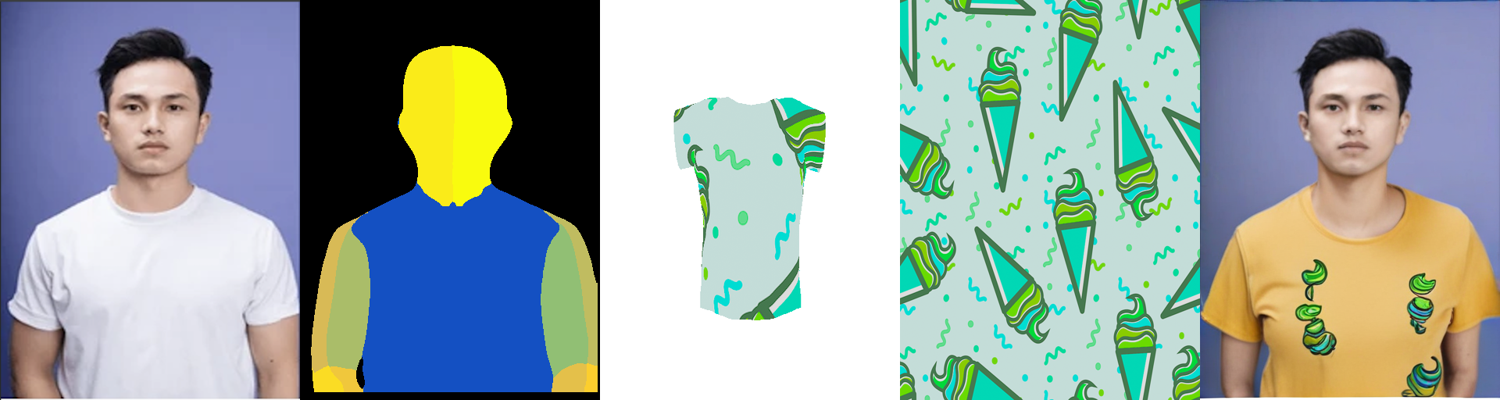

--------------------------------------------------------------------------------
👤 Kişi 2  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


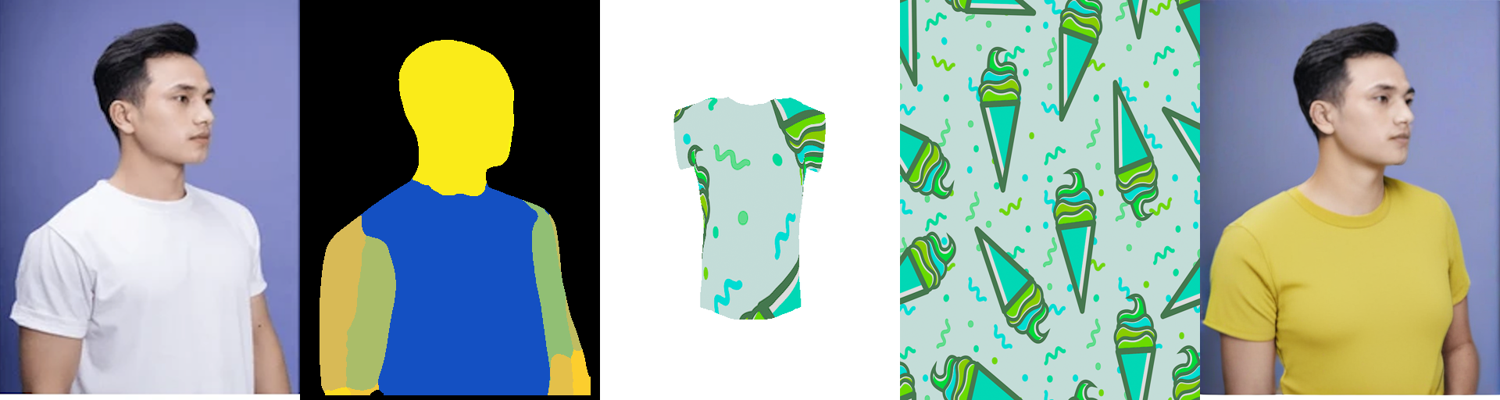

--------------------------------------------------------------------------------
👤 Kişi 3  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


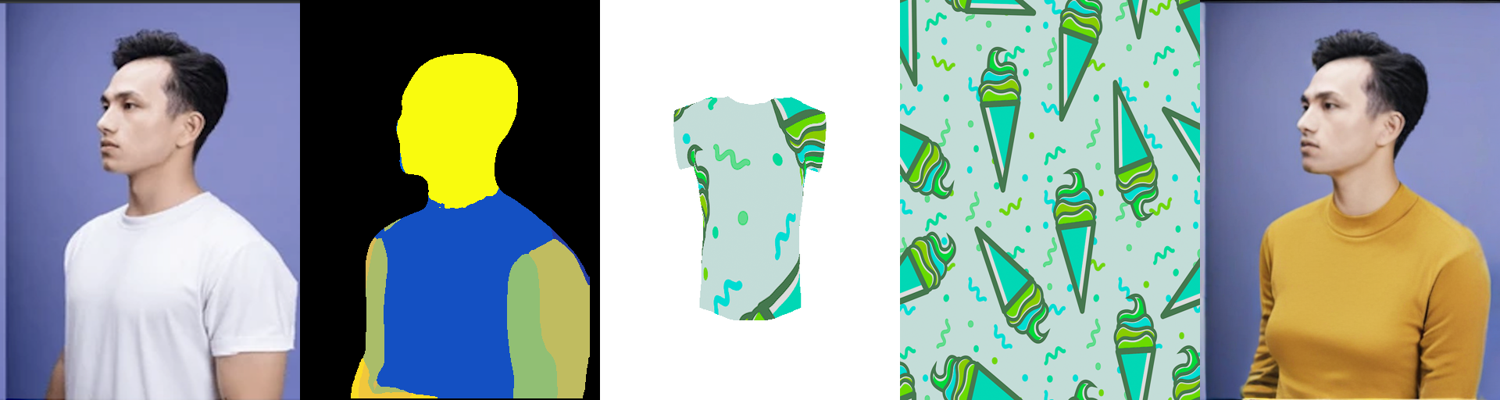

--------------------------------------------------------------------------------
👤 Kişi 4  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


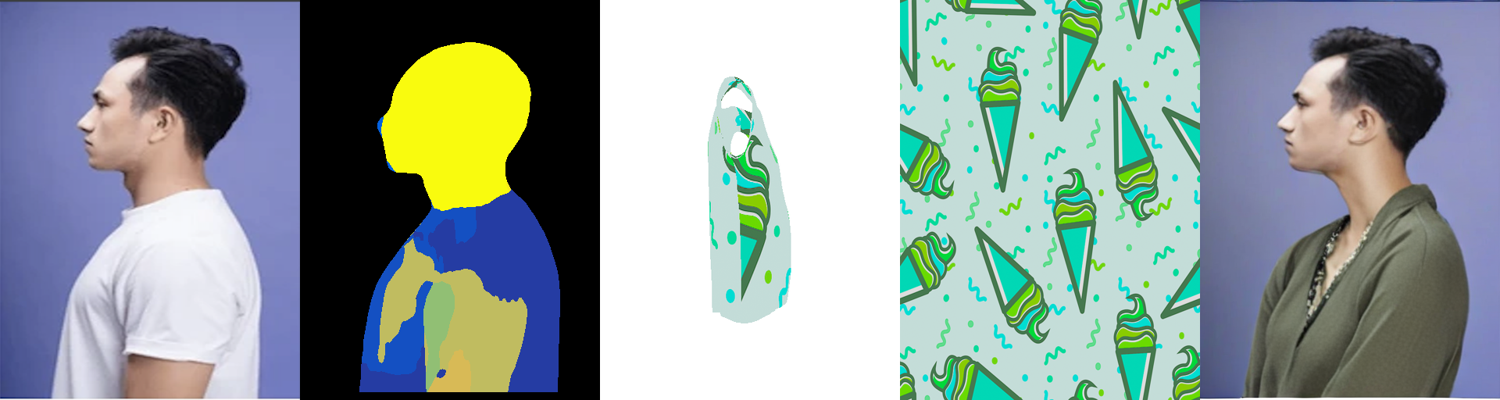

--------------------------------------------------------------------------------
👤 Kişi 5  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


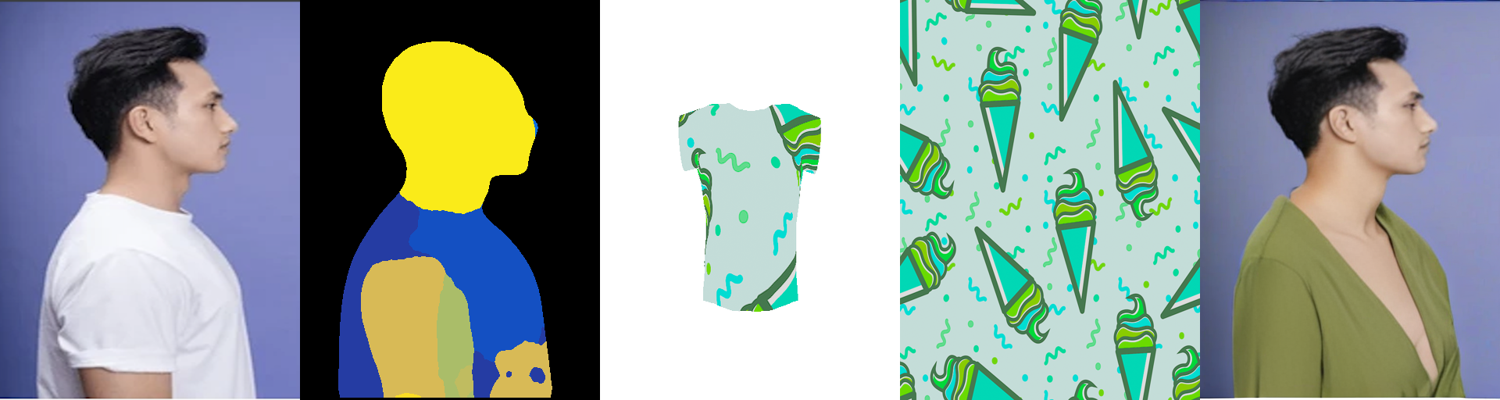

--------------------------------------------------------------------------------
👤 Kişi 6  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç


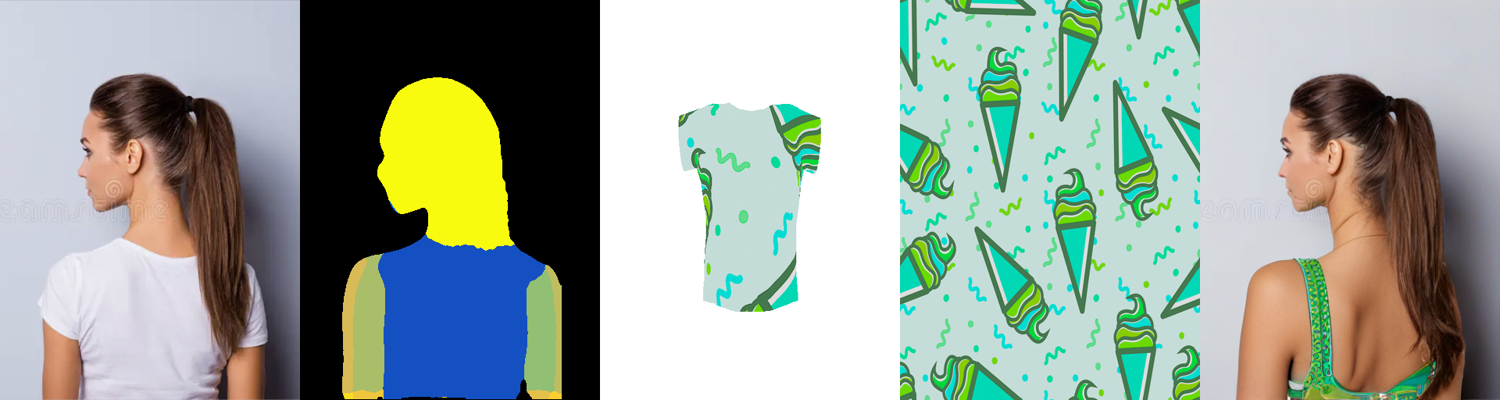

--------------------------------------------------------------------------------


In [14]:
from IPython.display import display
from PIL import Image

n = len(results)
if n > 0:
    print(f"Toplam {n} sonuç gösteriliyor...\n")
    for i, (h, p, mesh_render, garment_appearance, r) in enumerate(results):
        print(f"👤 Kişi {i+1}  |  🕺 DensePose  |  🖼️ 3D Mesh Render |  👕 Giysi Görünümü  |  ✨ Sonuç")
        w, hh = h.width, h.height
        combined = Image.new('RGB', (w * 5, hh))
        combined.paste(h, (0, 0))
        combined.paste(p.resize((w, hh)), (w, 0))
        combined.paste(mesh_render.resize((w, hh)), (w * 2, 0))
        combined.paste(garment_appearance.resize((w, hh)), (w * 3, 0))
        combined.paste(r.resize((w, hh)), (w * 4, 0))
        combined.thumbnail((1500, 600))
        display(combined)
        print("-" * 80)
else:
    print("Gösterilecek sonuç yok. Üstteki hücrenin başarıyla tamamlandığından emin ol.")

In [ ]:
# ============================================================
# PROBE SETUP — Drive'daki zip'leri data/ yapısına aç (Probe 0 & A için)
# Küçük zip'ler default; images.zip 1.69GB → EXTRACT_IMAGES=True ile aç (parite için)
# ============================================================
import os, glob, zipfile, shutil

DRIVE = '/content/drive/MyDrive/MeshVTON'
ROOT  = '/content/MeshVTON/data'
EXTRACT_IMAGES = False   # Probe A poz paritesi için True yap (yavaş)

JOBS = {
    'renders_3d.zip':   f'{ROOT}/processed/renders_3d',
    'normal_maps.zip':  f'{ROOT}/processed/normal_maps',
    'depth_maps.zip':   f'{ROOT}/processed/depth_maps',
    'smplx_params.zip': f'{ROOT}/processed/smplx_params',
    'agnostic.zip':     f'{ROOT}/processed/agnostic',
    'densepose.zip':    f'{ROOT}/processed/densepose',
}
if EXTRACT_IMAGES:
    JOBS['images.zip'] = f'{ROOT}/raw/images'

def _extract_flat(zip_path, target):
    """Zip'i target'a aç; iç içe klasör varsa dosyaları target'a düzleştir."""
    os.makedirs(target, exist_ok=True)
    if glob.glob(os.path.join(target, '*')):
        print(f"  • {os.path.basename(zip_path)} → zaten dolu, atlandı")
        return
    tmp = target + '_tmp'
    shutil.rmtree(tmp, ignore_errors=True); os.makedirs(tmp)
    with zipfile.ZipFile(zip_path) as z: z.extractall(tmp)
    n = 0
    for dp, _, fns in os.walk(tmp):
        for fn in fns:
            shutil.move(os.path.join(dp, fn), os.path.join(target, fn)); n += 1
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"  • {os.path.basename(zip_path)} → {target}  ({n} dosya)")

for z, tgt in JOBS.items():
    zp = os.path.join(DRIVE, z)
    if os.path.exists(zp): _extract_flat(zp, tgt)
    else: print(f"  ✗ {z} bulunamadı")

# pairs csv
os.makedirs(f'{ROOT}/raw', exist_ok=True)
for c in ['train_pairs.csv', 'val_pairs.csv', 'test_pairs.csv']:
    src = os.path.join(DRIVE, c)
    if os.path.exists(src) and not os.path.exists(f'{ROOT}/raw/{c}'):
        shutil.copy(src, f'{ROOT}/raw/{c}'); print(f"  • {c} → {ROOT}/raw/")
print("✅ setup bitti — şimdi Probe 0 ve Probe A çalışır")


  • renders_3d.zip → /content/MeshVTON/data/processed/renders_3d  (5000 dosya)
  • normal_maps.zip → /content/MeshVTON/data/processed/normal_maps  (5000 dosya)
  • depth_maps.zip → /content/MeshVTON/data/processed/depth_maps  (5000 dosya)
  • smplx_params.zip → /content/MeshVTON/data/processed/smplx_params  (13679 dosya)


KeyboardInterrupt: 

In [ ]:
# ============================================================
# PROBE 0 — Envanter: checkpoint + eğitim verisi boyutu + örnek render'lar
# ============================================================
import os, glob, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image

print("="*60); print("PROBE 0 — ENVANTER"); print("="*60)

# --- 1) Yüklü ControlNet3D checkpoint (cell-8 ile aynı glob) ---
ck = glob.glob('/content/drive/MyDrive/MeshVTON/checkpoints_meshvton/controlnet3d_final.pt') \
   + sorted(glob.glob('/content/drive/MyDrive/MeshVTON/checkpoints_meshvton/controlnet3d_*.pt')) \
   + sorted(glob.glob('/content/MeshVTON/checkpoints_meshvton/*.pt'))
if ck:
    p = ck[0]; sd = torch.load(p, map_location='cpu')
    nparam = sum(v.numel() for v in sd.values() if hasattr(v, 'numel'))
    print(f"✓ checkpoint: {p}\n  boyut={os.path.getsize(p)/1e6:.1f} MB | tensör={len(sd)} | param={nparam:,}")
    print(f"  (yüklü `controlnet` ile aynı olmalı; ~485MB / ControlNet3D-only beklenir)")
else:
    print("✗ ControlNet3D checkpoint bulunamadı")

# --- 2) Eğitim verisi boyutu ---
DATA_ROOTS = ['/content/MeshVTON/data', '/content/drive/MyDrive/MeshVTON/data', 'data']
root = next((r for r in DATA_ROOTS if os.path.isdir(os.path.join(r, 'processed', 'renders_3d'))), None)
if root is None:
    print("⚠️  processed/renders_3d hiçbir yolda yok → eğitim verisi Colab'a mount edilmemiş.")
    print("    Bu durumda 'kaç çift' sorusu için veriyi /content/MeshVTON/data altına bağla.")
else:
    nr = len(glob.glob(os.path.join(root, 'processed', 'renders_3d', '*.png')))
    nn = len(glob.glob(os.path.join(root, 'processed', 'normal_maps', '*.png')))
    nd = len(glob.glob(os.path.join(root, 'processed', 'depth_maps', '*.png')))
    print(f"data_root={root}")
    print(f"  renders_3d={nr}  normal_maps={nn}  depth_maps={nd}  (3D conditioning'i olan ÇİFT sayısı ≈ {nr})")
    try:
        from src.data.dataset import MeshVTONDataset
        pf = next((p for p in [os.path.join(root,'raw','train_pairs.csv'),
                               '/content/drive/MyDrive/MeshVTON/train_pairs.csv']
                   if os.path.exists(p)), None)
        ds = MeshVTONDataset(pairs_file=pf, data_root=root, height=512, width=384)  # 'X/Y pairs have 3D renders' basar
        print(f"  MeshVTONDataset uzunluğu = {len(ds)}")
    except Exception as e:
        print(f"  (MeshVTONDataset kurulamadı: {e})")

    # --- 3) Örnek render üçlüleri (render / normal / depth) ---
    rfiles = sorted(glob.glob(os.path.join(root, 'processed', 'renders_3d', '*.png')))
    show = rfiles[:: max(1, len(rfiles)//4)][:4] if rfiles else []
    if show:
        fig, ax = plt.subplots(len(show), 3, figsize=(8, 3*len(show))); ax = np.atleast_2d(ax)
        for i, rf in enumerate(show):
            stem = os.path.basename(rf)
            for j, sub in enumerate(['renders_3d', 'normal_maps', 'depth_maps']):
                fp = os.path.join(root, 'processed', sub, stem)
                if os.path.exists(fp):
                    ax[i, j].imshow(Image.open(fp));
                ax[i, j].set_title(f"{sub}\n{stem[:24]}", fontsize=7); ax[i, j].axis('off')
        plt.tight_layout(); plt.show()
        print("HÜKÜM: render'lar dokulu & poza uygun mu? Gri/blob ise → Probe D ile aynı doku kök nedeni.")


In [ ]:
# ============================================================
# PROBE A — Eğitim ↔ Çıkarım conditioning paritesi
# Eğitimdeki kayıtlı render ile build_conditioning_3d'nin canlı render'ı eşleşiyor mu?
# Ayrıca eğitimdeki poz kaynağı (cached smplx .npz) ile inference estimator'ı aynı mı?
# ============================================================
import os, glob, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image

print("="*60); print("PROBE A — TRAIN/INFER PARİTE"); print("="*60)

DATA_ROOTS = ['/content/MeshVTON/data', '/content/drive/MyDrive/MeshVTON/data', 'data']
root = next((r for r in DATA_ROOTS if os.path.isdir(os.path.join(r, 'processed', 'renders_3d'))), None)

if root is None:
    print("⚠️  Yerel/Drive eğitim verisi (processed/renders_3d) bulunamadı → PROBE A atlandı.")
    print("    Veri Colab'a mount edilince bu probe parite ölçecek.")
else:
    rdir = os.path.join(root, 'processed', 'renders_3d')
    files_r = sorted(glob.glob(os.path.join(rdir, '*.png')))
    print(f"data_root={root}  | kayıtlı render sayısı={len(files_r)}")
    sample = files_r[0]
    stem = os.path.splitext(os.path.basename(sample))[0]   # "{person}_{garment}"
    stored = np.asarray(Image.open(sample).convert("RGB").resize((384, 512))) / 255.0
    print(f"örnek: {stem}")

    # Kayıtlı render'ın renk bilgisi (parite + Probe D ile tutarlılık)
    m = stored.mean(2) < 0.96
    fg = stored[m] if m.sum() else stored.reshape(-1, 3)
    print(f"kayıtlı render fg std={fg.std():.3f}  (düşük→eğitim verisi de gri/desensiz)")

    # Poz kaynağı paritesi: cached smplx .npz global_orient vs estimator
    from src.modules.conditioning3d import azim_from_global_orient
    person_id = stem.rsplit('_', 1)[0]
    npz = glob.glob(os.path.join(root, 'processed', 'smplx*', f'{person_id}*.npz')) \
        + glob.glob(os.path.join(root, 'processed', '**', f'{person_id}*.npz'), recursive=True)
    img = glob.glob(os.path.join(root, 'raw', 'images', f'{person_id}.*'))
    if npz and img:
        cached = dict(np.load(npz[0]))
        az_cached = azim_from_global_orient(cached['global_orient']) if 'global_orient' in cached else None
        hum = Image.open(img[0]).convert("RGB").resize((384, 512))
        est = estimator.estimate(np.array(hum)[:, :, ::-1].copy())
        az_est = azim_from_global_orient(est['global_orient'])
        print(f"global_orient azim — cached(train)={az_cached}  vs  estimator(infer)={az_est:.0f}")
        if az_cached is not None and abs((az_cached - az_est + 180) % 360 - 180) > 20:
            print("  ❌ poz kaynağı DRIFT → train render farklı pozda üretilmiş (parite kırık)")
        else:
            print("  ✅ poz kaynağı tutarlı")
    else:
        print("cached smplx .npz / person image bulunamadı → poz paritesi karşılaştırılamadı")

    plt.figure(figsize=(3.5, 4.5)); plt.imshow(stored)
    plt.title(f"kayıtlı eğitim render\n{stem}", fontsize=9); plt.axis('off'); plt.show()

    print("\n" + "-"*60)
    print("HÜKÜM: kayıtlı render gri/desensizse → eğitim de aynı doku sorunundan etkilenmiş (Probe D ile aynı kök).")
    print("       cached vs estimator azim farklıysa → train/infer poz drift'i (yeniden render gerekebilir).")


In [ ]:
# ============================================================
# PROBE B — Poz/yön doğruluğu (arka→ön bug'ının kanıtı)
# Beklenen: ön≈0°, arka≈180°, yan≈90/270°.
# (Mevcut çıktıda ön kişi 182°, arka kadın 347° çıkmıştı → ~180° offset şüphesi.)
# ============================================================
import os, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from src.modules.conditioning3d import azim_from_global_orient

print("="*60); print("PROBE B — POZ / YÖN"); print("="*60)

# Test görselleri: en son yüklenen person_files varsa onları kullan
if 'person_files' in globals() and person_files:
    test_imgs = person_files
else:
    from google.colab import files
    print("Ön/yan/arka test görselleri yükle (ideal: aynı kişinin 4 açısı):")
    test_imgs = list(files.upload().keys())

def autocrop_person(pil):
    """Beyaz/uniform kenarları kırp → HMR2'ye daha sıkı bbox (bbox etkisini test eder)."""
    a = np.array(pil.convert("RGB")); fg = a.mean(2) < 245
    ys, xs = np.where(fg)
    if len(xs) < 20: return pil
    return pil.crop((int(xs.min()), int(ys.min()), int(xs.max())+1, int(ys.max())+1))

rows = []
print(f"\n{'dosya':<42}{'azim':>7}{'azim-180':>10}{'crop_azim':>11}")
for pf in test_imgs:
    human = Image.open(pf).convert("RGB").resize((384, 512))
    p_full = estimator.estimate(np.array(human)[:, :, ::-1].copy())
    az_full = azim_from_global_orient(p_full['global_orient'])
    hc = autocrop_person(Image.open(pf).convert("RGB")).resize((384, 512))
    p_crop = estimator.estimate(np.array(hc)[:, :, ::-1].copy())
    az_crop = azim_from_global_orient(p_crop['global_orient'])
    print(f"{os.path.basename(pf)[:40]:<42}{az_full:>7.0f}{(az_full-180)%360:>10.0f}{az_crop:>11.0f}")
    rows.append((os.path.basename(pf), human, az_full))

# Görsel: kişi + (estimated azim) küçük etiket
n = len(rows)
fig, ax = plt.subplots(1, n, figsize=(2.4*n, 3.2)); ax = np.atleast_1d(ax)
for i, (name, hum, az) in enumerate(rows):
    ax[i].imshow(hum); ax[i].set_title(f"azim={az:.0f}°", fontsize=9); ax[i].axis('off')
plt.tight_layout(); plt.show()

print("\n" + "-"*60)
if len(rows) < 2:
    print("⚠️  Tek görsel yüklendi → sonuç tek başına yargı için YETERSİZ.")
    print("    Aynı kişinin ÖN + ARKA (+ yan) görsellerini birlikte yükleyip tekrar koştur.")
print("HÜKÜM kılavuzu: ön≈0°, arka≈180° beklenir.")
print("  • DİKKAT: kanıtlar azim'in SABİT 180° offset OLMADIĞINI, kişiden kişiye")
print("    TUTARSIZ olduğunu gösteriyor (HMR2 monoküler ön/arka belirsizliği).")
print("    → Bu yüzden sabit (yaw+180) uygulamayın; doğru çıkanları bozar.")
print("  • crop_azim == full_azim ise bbox SORUN DEĞİL (dedektör gerekmez).")
print("  • FIX-2 (önerilen): (a) VIEW_ANGLE ile elle override (0/90/180/270),")
print("    (b) orta vade: densepose/parsing'ten ön-arka tespiti → azim'i ona göre 0/180 kilitle.")


In [ ]:
# ============================================================
# PROBE C — ControlNet3D "ısırıyor mu" (şekli gerçekten zorluyor mu)
# (1) residual normları ~0 mı?  (2) çıktı controlnet_3d ile/siz değişiyor mu?
# ============================================================
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from src.modules.conditioning3d import build_conditioning_3d

print("="*60); print("PROBE C — CONTROLNET3D ETKİSİ"); print("="*60)

# --- (1) residual büyüklükleri ---
if 'person_files' in globals() and person_files:
    human0 = Image.open(person_files[0]).convert("RGB").resize((384, 512))
else:
    from google.colab import files
    print("Bir kişi görseli yükle:"); human0 = Image.open(list(files.upload().keys())[0]).convert("RGB").resize((384, 512))

az = locals().get('VIEW_ANGLE', None)
cond = build_conditioning_3d(human0, MESH_PATH, estimator, renderer, draper,
                             height=512, width=384, view_angle=az, device='cuda', dtype=torch.float16)
cond3d = cond['conditioning_3d']; render_rgb = cond['render_rgb']

with torch.no_grad(), torch.amp.autocast('cuda'):
    t = torch.tensor([500], device='cuda')
    res = controlnet(cond3d.to(torch.float16), t.expand(cond3d.shape[0]))
print("ControlNet3D residual seviye-başı |L2| / |mean|:")
zero_like = 0
for i, r in enumerate(res):
    rl2 = r.float().norm().item(); rm = r.float().abs().mean().item()
    print(f"  level {i:2d}: shape={tuple(r.shape)}  L2={rl2:.4f}  mean|·|={rm:.6f}")
    if rm < 1e-4: zero_like += 1
print(f"  → ~sıfır seviye sayısı: {zero_like}/{len(res)}")

# --- (2) çıktı ablasyonu: tam vs controlnet kapalı ---
def _pose_and_mask(human):
    kp = openpose_model(human); parse, _ = parsing_model(human)
    cat = 'upper_body'
    msk, _ = get_mask_location('hd', cat, parse, kp); msk = msk.resize((384, 512))
    arg = convert_PIL_to_numpy(_apply_exif_orientation(human), format="BGR")
    a = apply_net.create_argument_parser().parse_args(('show',
        '/content/IDM-VTON-official/configs/densepose_rcnn_R_50_FPN_s1x.yaml',
        '/content/IDM-VTON-official/ckpt/densepose/model_final_162be9.pkl',
        'dp_segm', '-v', '--opts', 'MODEL.DEVICE', 'cuda'))
    ps = Image.fromarray(a.func(a, arg)[:, :, ::-1]).resize((384, 512))
    return ps, msk

ps, msk = _pose_and_mask(human0)
with torch.no_grad(), torch.amp.autocast('cuda'):
    pe, npe, ppe, nppe = pipe.encode_prompt("model is wearing clothes", num_images_per_prompt=1,
        do_classifier_free_guidance=True, negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality")
    pe_c, _, _, _ = pipe.encode_prompt(["a photo of clothes"], num_images_per_prompt=1, do_classifier_free_guidance=False)

def _run(cn, c3d):
    with torch.no_grad(), torch.amp.autocast('cuda'):
        return pipe(prompt_embeds=pe.cuda().half(), negative_prompt_embeds=npe.cuda().half(),
            pooled_prompt_embeds=ppe.cuda().half(), negative_pooled_prompt_embeds=nppe.cuda().half(),
            num_inference_steps=30, generator=torch.Generator('cuda').manual_seed(42), strength=1.0,
            pose_img=tfm(ps).unsqueeze(0).cuda().half(), text_embeds_cloth=pe_c.cuda().half(),
            cloth=tfm(render_rgb).unsqueeze(0).cuda().half(), mask_image=msk, image=human0,
            height=512, width=384, ip_adapter_image=render_rgb, guidance_scale=2.0,
            controlnet_3d=cn, conditioning_3d=c3d)[0][0]

out_full = _run(controlnet, cond3d)
out_off  = _run(None, None)
diff = np.abs(np.asarray(out_full, np.float32) - np.asarray(out_off, np.float32)).mean()

fig, ax = plt.subplots(1, 3, figsize=(11, 5))
ax[0].imshow(out_off);  ax[0].set_title('controlnet_3d KAPALI'); ax[0].axis('off')
ax[1].imshow(out_full); ax[1].set_title('controlnet_3d AÇIK');   ax[1].axis('off')
ax[2].imshow(np.abs(np.asarray(out_full,np.float32)-np.asarray(out_off,np.float32)).astype(np.uint8)); ax[2].set_title(f'fark (mean={diff:.1f})'); ax[2].axis('off')
plt.tight_layout(); plt.show()

print("\n" + "-"*60)
if zero_like > len(res) // 2 or diff < 5:
    print(f"HÜKÜM: ❌ FAIL — ControlNet3D çıktıyı neredeyse DEĞİŞTİRMİYOR (mean fark={diff:.1f}).")
    print("  Şekil zorlanmıyor → 2B halüsinasyon baskın. FIX-3: parite sağlandıktan sonra")
    print("  düzeltilmiş veriyle daha uzun/daha çok veriyle yeniden eğit.")
else:
    print(f"HÜKÜM: ✅ PASS — ControlNet3D çıktıyı belirgin değiştiriyor (mean fark={diff:.1f}).")


In [11]:
# ============================================================
# PROBE D — Giysi GÖRÜNÜM referansı (doku kaybı → halüsinasyon)
# Hipotez: cloth/ip_adapter olarak giden render desensiz/gri → model giysiyi uyduruyor
# ============================================================
import numpy as np, torch
import matplotlib.pyplot as plt
from src.modules.garment_draper import load_garment_mesh
from src.modules.conditioning3d import build_conditioning_3d
from PIL import Image

print("="*60); print("PROBE D — GİYSİ GÖRÜNÜM REFERANSI"); print("="*60)

g = load_garment_mesh(MESH_PATH)
vc  = np.asarray(g['vertex_colors'], dtype=np.float32)
tex = np.asarray(g['texture'])
n_uv_unique = len(np.unique(np.round(np.asarray(g['uv']), 4), axis=0)) if 'uv' in g else 0

print(f"mesh: {MESH_PATH}")
print(f"  vertex_colors: shape={vc.shape}  var={vc.var():.5f}  mean={np.round(vc.mean(0),3)}")
print(f"  texture: shape={tex.shape}  mean={tex.mean():.1f}  unique_colors={len(np.unique(tex.reshape(-1, tex.shape[-1]), axis=0))}")
print(f"  uv unique coords: {n_uv_unique}  (0/az → UV doku yok)")

# Düz gri fallback (0.7) tespiti: tüm vertex_colors sabit ~0.7 ise referans BOŞ
is_gray = vc.var() < 1e-3 or (np.abs(vc - 0.7).mean() < 0.02)

# render_rgb'yi göster (cloth + ip_adapter_image olarak buna gidiyor)
try:
    az = locals().get('VIEW_ANGLE', None)
    # bir kişi görseli varsa onun pozuyla, yoksa azim=0 ön ile render et
    if 'person_files' in globals() and person_files:
        human0 = Image.open(person_files[0]).convert("RGB").resize((384, 512))
        cond = build_conditioning_3d(human0, MESH_PATH, estimator, renderer, draper,
                                     height=512, width=384, view_angle=az,
                                     device='cuda', dtype=torch.float16)
    else:
        cond = build_conditioning_3d(Image.new("RGB", (384, 512), (127, 127, 127)),
                                     MESH_PATH, estimator, renderer, draper,
                                     height=512, width=384, view_angle=0,
                                     device='cuda', dtype=torch.float16)
    rr = np.asarray(cond['render_rgb'])
    fig, ax = plt.subplots(1, 2, figsize=(7, 5))
    ax[0].imshow(rr); ax[0].set_title(f"render_rgb (cloth/ip ref)\nazim={cond['azim']:.0f}°"); ax[0].axis('off')
    # giysi maskesi içindeki renk varyansı (arka plan beyazını çıkar)
    m = (rr.mean(2) < 245)
    fg = rr[m] / 255.0 if m.sum() > 0 else rr.reshape(-1, 3) / 255.0
    ax[1].hist(fg.reshape(-1), bins=40); ax[1].set_title(f"render renk dağılımı\nfg std={fg.std():.3f}")
    plt.tight_layout(); plt.show()
    render_low_info = fg.std() < 0.06
except Exception as e:
    print("render_rgb gösterilemedi:", e); render_low_info = is_gray

print("\n" + "-"*60)
if is_gray or render_low_info:
    print("HÜKÜM: ❌ FAIL — Giysi referansı GRİ/DESENSİZ.")
    print("  GarmentNet/IP-Adapter düz ürün fotoğrafı bekler; bu render desensiz →")
    print("  model giysiyi UYDURUYOR (puantiyeli/çiçekli halüsinasyon). FIX-1 gerekli:")
    print("  görünümü geometriden ayır (gerçek düz giysi foto = cloth/ip; render = sadece conditioning_3d)")
    print("  veya TexturesVertex→TexturesUV ile deseni koru.")
else:
    print("HÜKÜM: ✅ PASS — referansta gerçek renk/desen var.")


PROBE D — GİYSİ GÖRÜNÜM REFERANSI
mesh: mesh (7).obj
  vertex_colors: shape=(1284, 3)  var=0.00000  mean=[0.392 0.392 0.392]
  texture: shape=(2, 2, 3)  mean=100.0  unique_colors=1
  uv unique coords: 1284  (0/az → UV doku yok)

------------------------------------------------------------
HÜKÜM: ❌ FAIL — Giysi referansı GRİ/DESENSİZ.
  GarmentNet/IP-Adapter düz ürün fotoğrafı bekler; bu render desensiz →
  model giysiyi UYDURUYOR (puantiyeli/çiçekli halüsinasyon). FIX-1 gerekli:
  görünümü geometriden ayır (gerçek düz giysi foto = cloth/ip; render = sadece conditioning_3d)
  veya TexturesVertex→TexturesUV ile deseni koru.
